In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/ecommerce_product_dataset.csv')
df

,nama_produk,harga,rating,jumlah_terjual,lokasi_penjual,brand,kategori,kondisi,platform
0,ZTE Nubia Z50 (5G) (12GB/256GB) (The Best Of C...,9499000,NaN,0,Kota Administrasi Jakarta Barat,Zte,Hp,Baru,Tokopedia
1,ZTE Nubia Redmagic 8s Pro 16GB/512GB Garansi R...,14999000,NaN,0,Kota Administrasi Jakarta Barat,Zte,Hp,Baru,Tokopedia
2,ZTE Nubia Z50 (5G) (12GB/256GB) (Jaminan Produ...,9499000,NaN,0,Kota Administrasi Jakarta Barat,Zte,Hp,Baru,Tokopedia
3,Digitalisme x Promo Nubia RedMagic 11 Pro 16GB...,17652000,5.0,6,Kota Administrasi Jakarta Pusat,Zte,Hp,Baru,Tokopedia
4,ZTE AXON 30 ULTRA 5G SD888 12GB 256GB 128GB BL...,70652400,NaN,0,Kota Administrasi Jakarta Selatan,Zte,Hp,Baru,Tokopedia
...,...,...,...,...,...,...,...,...,...
35445,ZTE F670L Port Hijau Ijo Unit Only,160000,NaN,0,Tidak Diketahui,Zte,Hp,Bekas,Shopee
35446,ZTE F670L,165000,5.0,139,Tidak Diketahui,Zte,Hp,Bekas,Shopee
35447,ZTE Nubia exAndromax,121000,5.0,1,Tangerang,Zte,Hp,Bekas,Shopee
35448,ZTE MYREPUBIK ZTE F670L,160000,NaN,2,Tidak Diketahui,Zte,Hp,Bekas,Shopee


In [3]:
df['brand'] = df['brand'].str.strip().str.title()
df['kategori'] = df['kategori'].str.strip().str.title()
df['kondisi'] = df['kondisi'].str.strip().str.title()

In [4]:
df_hp = df[df['kategori'] == 'Hp'].copy()

In [5]:
df_hp.columns

Index(['nama_produk', 'harga', 'rating', 'jumlah_terjual', 'lokasi_penjual',
       'brand', 'kategori', 'kondisi', 'platform'],
      dtype='str')

In [6]:
print(f"Jumlah data HP     : {len(df_hp)}")


Jumlah data HP     : 20354


# **Brand Dominance**

In [7]:
def analisis_brand_dominance(data, kategori_nama):
    print(f"{'='*60}")
    print(f"BRAND DOMINANCE - KATEGORI {kategori_nama.upper()}")
    print(f"{'='*60}")

    brand_summary = data.groupby('brand').agg(
        jumlah_listing=('nama_produk', 'count'),
        total_terjual=('jumlah_terjual', 'sum'),
        rata_harga=('harga', 'mean'),
        rata_rating=('rating', 'mean')
    ).reset_index()

    brand_summary['market_share_listing(%)'] = (brand_summary['jumlah_listing'] / brand_summary['jumlah_listing'].sum() * 100).round(2)
    brand_summary['market_share_terjual(%)'] = (brand_summary['total_terjual'] / brand_summary['total_terjual'].sum() * 100).round(2)
    brand_summary = brand_summary.sort_values('total_terjual', ascending=False)

    print(brand_summary.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    top10 = brand_summary.head(10)

    axes[0].barh(top10['brand'], top10['market_share_listing(%)'], color='steelblue')
    axes[0].set_title(f'Market Share berdasarkan Jumlah Listing - {kategori_nama}')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Market Share (%)')

    axes[1].barh(top10['brand'], top10['market_share_terjual(%)'], color='darkorange')
    axes[1].set_title(f'Market Share berdasarkan Unit Terjual - {kategori_nama}')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Market Share (%)')

    plt.tight_layout()
    plt.show()
    return brand_summary

BRAND DOMINANCE - KATEGORI HP
     brand  jumlah_listing  total_terjual   rata_harga  rata_rating  market_share_listing(%)  market_share_terjual(%)
   Samsung            1283         407073 5.520559e+06     4.895597                     6.30                    16.40
     Apple            1109         383403 1.142073e+07     4.924931                     5.45                    15.44
      Poco            1069         349605 3.113646e+06     4.932677                     5.25                    14.08
    Xiaomi            1249         270782 2.863934e+06     4.901599                     6.14                    10.91
   Infinix            1406         194790 2.411184e+06     4.898238                     6.91                     7.85
    Realme            1521         171191 2.525334e+06     4.901657                     7.47                     6.90
     Nokia            1448         164877 5.708190e+05     4.866395                     7.11                     6.64
      Vivo            2292

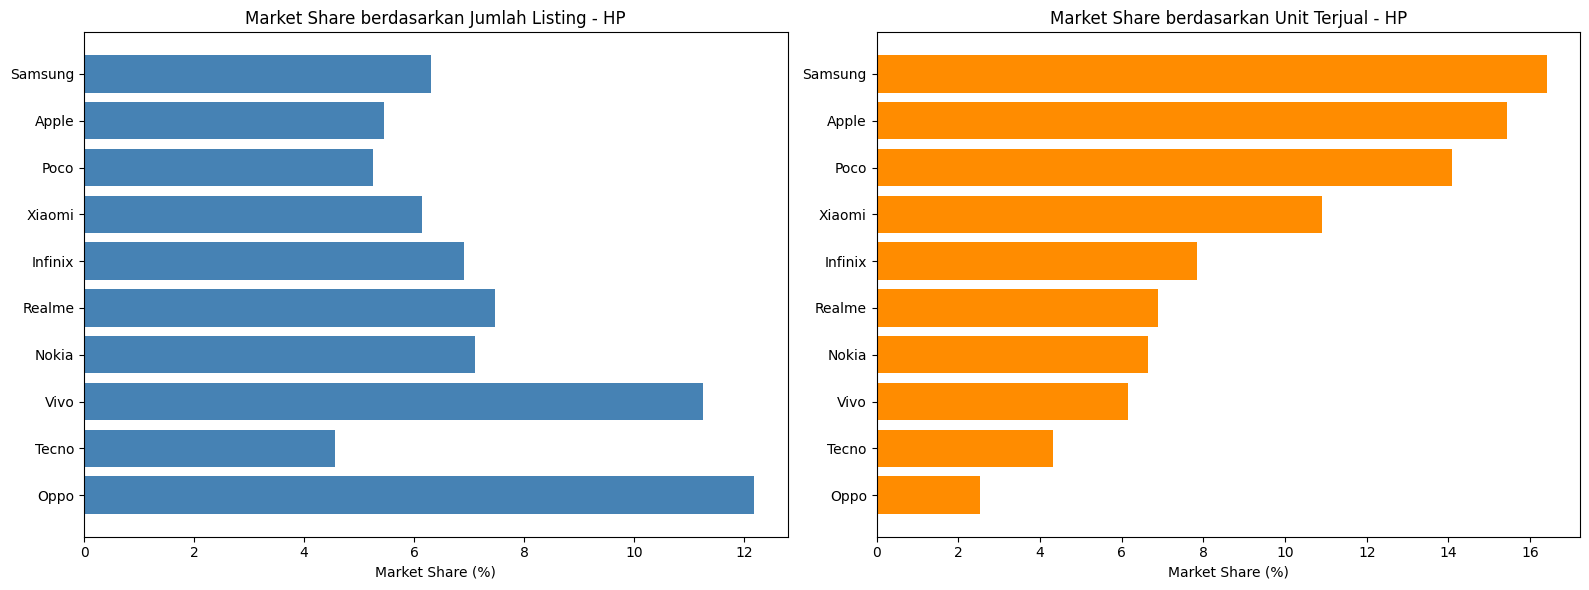

In [8]:
# === KODE KHUSUS HP ===
brand_summary_hp = analisis_brand_dominance(df_hp, 'HP')

# **Price Anomaly**

In [9]:
def analisis_price_anomaly(data, kategori_nama, min_listing=5):
    print(f"{'='*60}")
    print(f"PRICE ANOMALY DETECTION - KATEGORI {kategori_nama.upper()}")
    print(f"{'='*60}")

    hasil = []
    for brand, grup in data.groupby('brand'):
        if len(grup) < min_listing:
            continue
        Q1, Q3 = grup['harga'].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        batas_bawah, batas_atas = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        anomaly = grup[(grup['harga'] < batas_bawah) | (grup['harga'] > batas_atas)].copy()
        if len(anomaly) == 0:
            continue
        anomaly['tipe_anomaly'] = np.where(anomaly['harga'] > batas_atas, 'Overpriced', 'Underpriced/Suspicious')
        anomaly['batas_bawah'], anomaly['batas_atas'] = batas_bawah, batas_atas
        hasil.append(anomaly)

    df_anomaly = pd.concat(hasil) if hasil else pd.DataFrame()
    print(f"Total produk anomali: {len(df_anomaly)} dari {len(data)} listing ({len(df_anomaly)/len(data)*100:.2f}%)")
    if len(df_anomaly) > 0:
        print(df_anomaly['tipe_anomaly'].value_counts())
        cols = ['nama_produk', 'brand', 'harga', 'batas_bawah', 'batas_atas', 'tipe_anomaly', 'platform']
        print("\nContoh produk paling 'Overpriced' (top 10):")
        print(df_anomaly[cols].sort_values('harga', ascending=False).head(10).to_string(index=False))

    top_brand = data['brand'].value_counts().head(8).index
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=data[data['brand'].isin(top_brand)], x='brand', y='harga')
    plt.title(f'Distribusi Harga & Outlier per Brand - {kategori_nama}')
    plt.xticks(rotation=45)
    plt.ylabel('Harga (Rp)')
    plt.tight_layout()
    plt.show()
    return df_anomaly

PRICE ANOMALY DETECTION - KATEGORI HP
Total produk anomali: 1448 dari 20354 listing (7.11%)
tipe_anomaly
Overpriced                1413
Underpriced/Suspicious      35
Name: count, dtype: int64

Contoh produk paling 'Overpriced' (top 10):
                                                                                                                                                                                nama_produk      brand     harga  batas_bawah  batas_atas tipe_anomaly  platform
Lenovo Legion 9 18IAX10 | 83EY0049ID | Intel Core Ultra 9-275HX | RTX5090 24GB | RAM 64GB | SSD 2TB | Layar 18"Inch WQUXGA IPS, 240Hz | Windows 11 Home + Microsoft Office Home 2024 - Unit     Lenovo 109999000   -3336250.0   6493750.0   Overpriced Tokopedia
                                                                                                                         ASUS ROG PHONE 5 RAM 16 ROM 256GB GARANSI 1 TAHUN SIM ALL OPERATOR       Asus  99999999   -7446000.0  16010000.0   Overpriced T

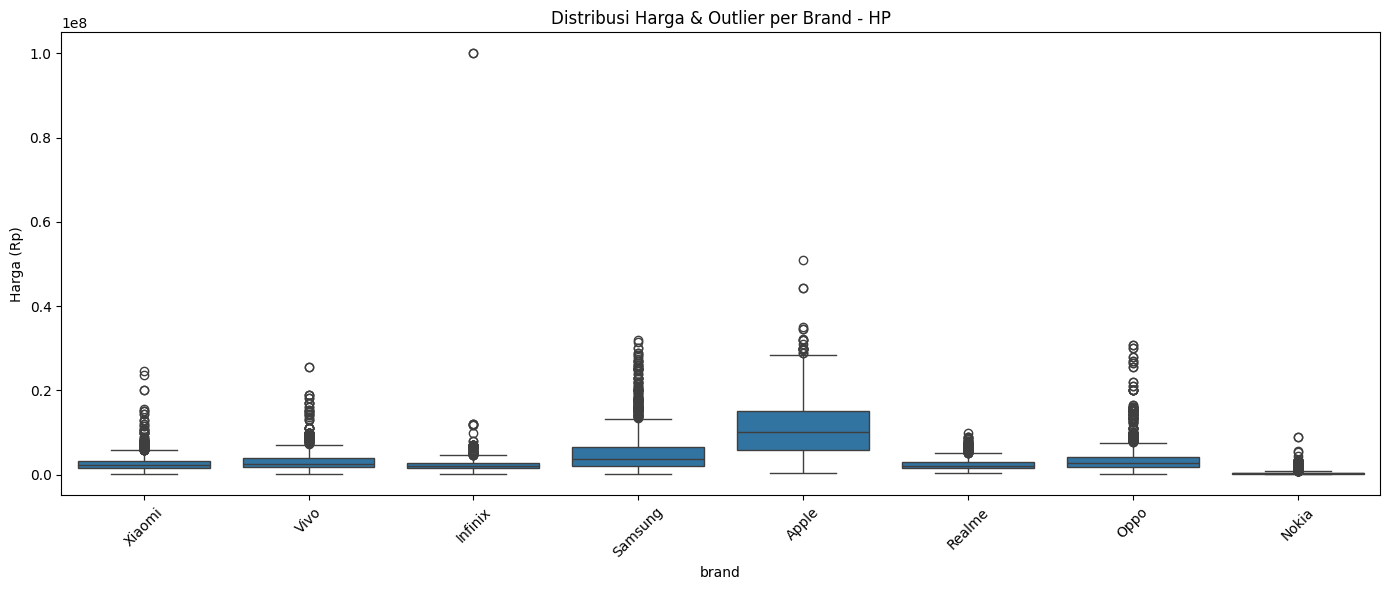

In [10]:
# === KODE KHUSUS HP ===
anomaly_hp = analisis_price_anomaly(df_hp, 'HP')

# **Analisis Depresiasi dan Likuiditas Pasar Bekas**

In [11]:
def analisis_depresiasi_likuiditas(data, kategori_nama, min_listing=5):
    print(f"{'='*60}")
    print(f"DEPRESIASI & LIKUIDITAS PASAR BEKAS - {kategori_nama.upper()}")
    print(f"{'='*60}")

    hasil = []
    for brand, grup in data.groupby('brand'):
        baru = grup[grup['kondisi'] == 'Baru']
        bekas = grup[grup['kondisi'] == 'Bekas']
        if len(baru) < min_listing or len(bekas) < min_listing:
            continue

        harga_baru, harga_bekas = baru['harga'].median(), bekas['harga'].median()
        depresiasi_pct = (1 - harga_bekas / harga_baru) * 100

        total_terjual_bekas = bekas['jumlah_terjual'].sum()
        avg_terjual_bekas = bekas['jumlah_terjual'].mean()
        pct_listing_terjual = (bekas['jumlah_terjual'] > 0).mean() * 100  # proksi likuiditas

        hasil.append({
            'brand': brand,
            'n_listing_baru': len(baru), 'n_listing_bekas': len(bekas),
            'median_harga_baru': harga_baru, 'median_harga_bekas': harga_bekas,
            'depresiasi(%)': round(depresiasi_pct, 2),
            'total_unit_terjual_bekas': total_terjual_bekas,
            'avg_unit_terjual_per_listing_bekas': round(avg_terjual_bekas, 2),
            'pct_listing_pernah_terjual(%)': round(pct_listing_terjual, 2)
        })

    df_hasil = pd.DataFrame(hasil).sort_values('depresiasi(%)', ascending=False)
    print(df_hasil.to_string(index=False))

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_hasil, x='depresiasi(%)', y='pct_listing_pernah_terjual(%)',
                     size='total_unit_terjual_bekas', sizes=(50, 800), legend=False)
    for _, row in df_hasil.iterrows():
        plt.text(row['depresiasi(%)'] + 0.3, row['pct_listing_pernah_terjual(%)'], row['brand'], fontsize=9)
    plt.axvline(df_hasil['depresiasi(%)'].median(), linestyle='--', color='gray', alpha=0.6)
    plt.axhline(df_hasil['pct_listing_pernah_terjual(%)'].median(), linestyle='--', color='gray', alpha=0.6)
    plt.title(f'Depresiasi vs Likuiditas Pasar Bekas per Brand - {kategori_nama}')
    plt.xlabel('Tingkat Depresiasi (%)')
    plt.ylabel('% Listing Bekas yang Pernah Terjual (Likuiditas)')
    plt.tight_layout()
    plt.show()
    return df_hasil

DEPRESIASI & LIKUIDITAS PASAR BEKAS - HP
     brand  n_listing_baru  n_listing_bekas  median_harga_baru  median_harga_bekas  depresiasi(%)  total_unit_terjual_bekas  avg_unit_terjual_per_listing_bekas  pct_listing_pernah_terjual(%)
     Apple             697              412         12549000.0           5050000.0          59.76                     72188                              175.21                          69.17
    Huawei             559              374          7555275.0           3650000.0          51.69                      2391                                6.39                          47.59
      Oppo            2089              391          2998000.0           1490000.0          50.30                     24264                               62.06                          75.45
   Samsung             847              436          4200000.0           2375000.0          43.45                     39325                               90.19                          93.12
    

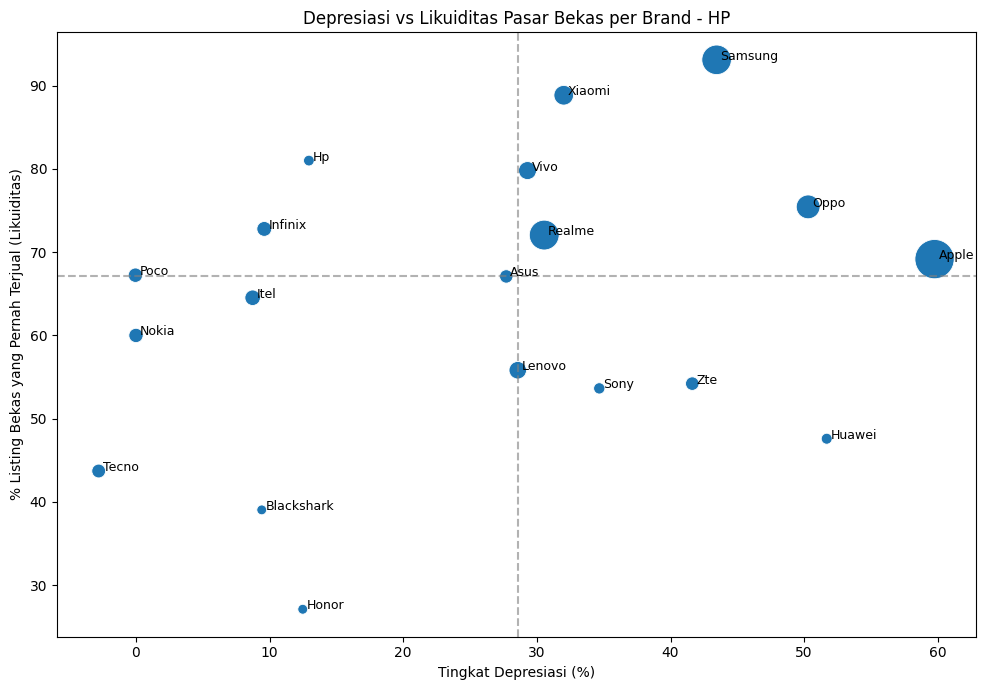

In [12]:
depresiasi_hp = analisis_depresiasi_likuiditas(df_hp, 'HP')

# **Herfindahl-Hirschman Index (HHI)**

In [13]:
def hitung_hhi(data, kategori_nama):
    print(f"{'='*60}")
    print(f"HERFINDAHL-HIRSCHMAN INDEX (HHI) - {kategori_nama.upper()}")
    print(f"{'='*60}")

    share_pct = data.groupby('brand')['jumlah_terjual'].sum()
    share_pct = share_pct / share_pct.sum() * 100
    hhi = (share_pct ** 2).sum()

    if hhi < 1500:
        interpretasi = "Pasar Kompetitif (tidak terkonsentrasi)"
    elif hhi < 2500:
        interpretasi = "Konsentrasi Moderat"
    else:
        interpretasi = "Pasar Terkonsentrasi Tinggi (oligopoli)"

    print(f"HHI (berbasis unit terjual): {hhi:.0f} -> {interpretasi}")
    return hhi

hhi_hp = hitung_hhi(df_hp, 'HP')

HERFINDAHL-HIRSCHMAN INDEX (HHI) - HP
HHI (berbasis unit terjual): 1054 -> Pasar Kompetitif (tidak terkonsentrasi)


# **Price Positioning Matrix**

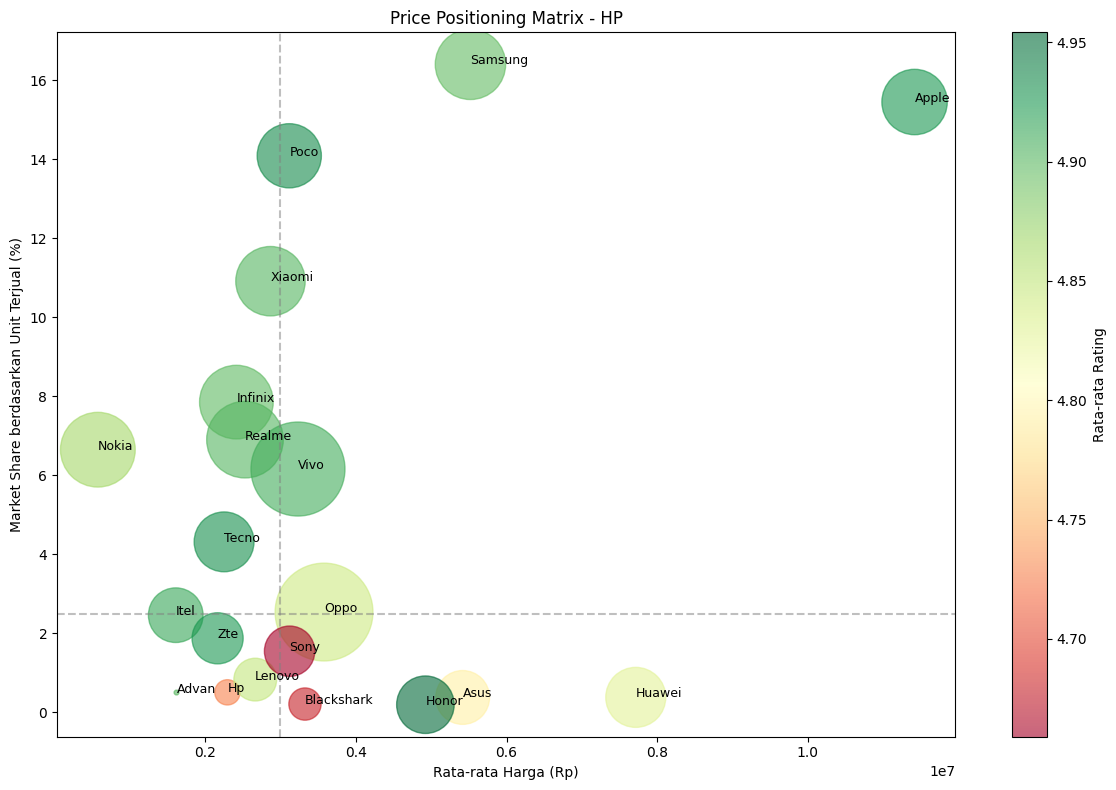

In [14]:
def price_positioning_matrix(data, kategori_nama):
    summary = data.groupby('brand').agg(
        avg_harga=('harga', 'mean'),
        total_terjual=('jumlah_terjual', 'sum'),
        n_listing=('nama_produk', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()
    summary = summary[summary['n_listing'] >= 5]
    summary['market_share(%)'] = summary['total_terjual'] / summary['total_terjual'].sum() * 100

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(summary['avg_harga'], summary['market_share(%)'],
                           s=summary['n_listing'] * 2, alpha=0.6,
                           c=summary['avg_rating'], cmap='RdYlGn')
    for _, row in summary.iterrows():
        plt.annotate(row['brand'], (row['avg_harga'], row['market_share(%)']), fontsize=9)
    plt.colorbar(scatter, label='Rata-rata Rating')
    plt.axvline(summary['avg_harga'].median(), linestyle='--', color='gray', alpha=0.5)
    plt.axhline(summary['market_share(%)'].median(), linestyle='--', color='gray', alpha=0.5)
    plt.xlabel('Rata-rata Harga (Rp)')
    plt.ylabel('Market Share berdasarkan Unit Terjual (%)')
    plt.title(f'Price Positioning Matrix - {kategori_nama}')
    plt.tight_layout()
    plt.show()
    return summary

positioning_hp = price_positioning_matrix(df_hp, 'HP')


# **Disparitas Harga Antar Platform**

DISPARITAS HARGA ANTAR PLATFORM - HP
 platform kondisi      mean    median  count
   Blibli    Baru 4100522.0 2743680.0   7659
   Shopee    Baru 3679759.0 2239000.0   3576
   Shopee   Bekas 2708908.0 1807944.0   3030
Tokopedia    Baru 4549433.0 2189000.0   3065
Tokopedia   Bekas 2991290.0 2000000.0   2946


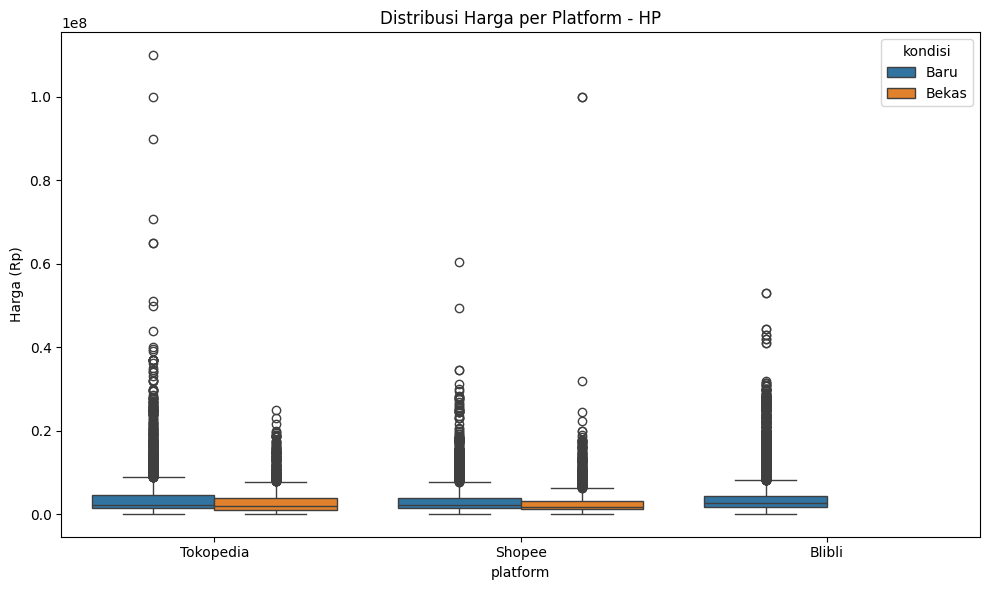

In [15]:
def analisis_disparitas_platform(data, kategori_nama):
    print(f"{'='*60}")
    print(f"DISPARITAS HARGA ANTAR PLATFORM - {kategori_nama.upper()}")
    print(f"{'='*60}")

    summary = data.groupby(['platform', 'kondisi'])['harga'].agg(['mean', 'median', 'count']).round(0).reset_index()
    print(summary.to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x='platform', y='harga', hue='kondisi')
    plt.title(f'Distribusi Harga per Platform - {kategori_nama}')
    plt.ylabel('Harga (Rp)')
    plt.tight_layout()
    plt.show()
    return summary

disparitas_hp = analisis_disparitas_platform(df_hp, 'HP')


# **Hidden Gems / Best Value Finder**

In [16]:
def cari_hidden_gems(data, kategori_nama, top_n=15):
    print(f"{'='*60}")
    print(f"HIDDEN GEMS (Best Value Products) - {kategori_nama.upper()}")
    print(f"{'='*60}")

    d = data[(data['rating'] > 0) & (data['jumlah_terjual'] > 0)].copy()
    d['z_harga_brand'] = d.groupby('brand')['harga'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    d['skor_value'] = (d['rating'].rank(pct=True) * 0.4 +
                        d['jumlah_terjual'].rank(pct=True) * 0.4 +
                        (1 - d['z_harga_brand'].rank(pct=True)) * 0.2)

    top = d.sort_values('skor_value', ascending=False).head(top_n)
    cols = ['nama_produk', 'brand', 'harga', 'rating', 'jumlah_terjual', 'kondisi', 'platform', 'skor_value']
    print(top[cols].to_string(index=False))
    return top

gems_hp = cari_hidden_gems(df_hp, 'HP')

HIDDEN GEMS (Best Value Products) - HP
                                                                                                                         nama_produk   brand   harga  rating  jumlah_terjual kondisi  platform  skor_value
                                                               iPhone X 256GB/64GB Second iPhone X Bekas Fullset Mulus 100% Original   Apple 2650000     5.0           10000   Bekas    Shopee    0.865615
                                                           iPhone XR 64GB / 128 GB / 256 GB Second Fullset Original Mulus / Like new   Apple 3390000     5.0           10000   Bekas    Shopee    0.863974
                                                               iPhone 11 Pro Max 64GB 256GB 512GB second Original 100% Mulus Fullset   Apple 4850000     5.0           10000   Bekas    Shopee    0.856825
  POCO C71 (4+4GB/128GB) Performa Cadas | Layar Cadas 6.88" 120Hz | Baterai Cadas 5200mAh | Expansi RAM hingga 8GB dan storage 128GB    Poco 1594000 